In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary
from preprocessing.PP_Processor import DataCollector
from preprocessing.SignalNoise_Process import SignalProcessor
from preprocessing.PP_Plots import Plotter
import math
import re

In [2]:
from utils.paths import DESCRIPTORS_DIR,DATABASE_DIR,RAW_DIR

In [3]:
dc = DataCollector()
pl = Plotter()
sp = SignalProcessor()

In [4]:
df_compo = pd.read_excel(RAW_DIR/'1_Ternary_exp.xlsx',sheet_name='composition')
com_Cu = df_compo.sort_values("Cu",ascending=False)['Cu'].to_numpy()
com_Ni = df_compo.sort_values("Ni",ascending=False)['Ni'].to_numpy()
com_Al = df_compo.sort_values("Al",ascending=False)['Al'].to_numpy()

In [5]:
df_compo = df_compo.copy()
df_compo = df_compo.dropna()

df_compo['Cu'] = (df_compo["Cu"] * 100).round(2)
df_compo['Ni'] = (df_compo["Ni"] * 100).round(2)
df_compo['Al'] = (df_compo["Al"] * 100).round(2)

df_compo["symbol"] = (
    "Cu" + df_compo["Cu"].astype(str) +
    " Ni" + df_compo["Ni"].astype(str) +
    " Al" + df_compo["Al"].astype(str)
)

In [29]:
df_compo.head(5)

,ID,Cu,Ni,Al,symbol
0,1,95.0,5.0,0.0,Cu95.0 Ni5.0 Al0.0
1,2,95.0,0.0,5.0,Cu95.0 Ni0.0 Al5.0
2,3,0.0,95.0,5.0,Cu0.0 Ni95.0 Al5.0
3,4,5.0,95.0,0.0,Cu5.0 Ni95.0 Al0.0
4,5,5.0,0.0,95.0,Cu5.0 Ni0.0 Al95.0


In [6]:
FOLDER = RAW_DIR/"_1st_bad_data_no_removed"
files_index, selected = dc.extract_file_names(FOLDER, pattern= re.compile(
    r"""
    sample(?P<sample>\d+)       # sample12
    .*?                         # anything in between (important!)
    pump_                       # pump_
    (?P<power>\d+)p0mW          # 10p0mW → captures 10
    """,
    
    re.VERBOSE
))

In [7]:
master_wvl = dc.build_master(selected, smooth="wvl", method="savgol", savgol_window=51, savgol_poly=3)
master_time = dc.build_master(selected, smooth="time", method="gaussian", gaussian_sigma=3)


In [8]:
df = master_wvl[1]
df = df.drop(columns=["sample", "power_mW"])

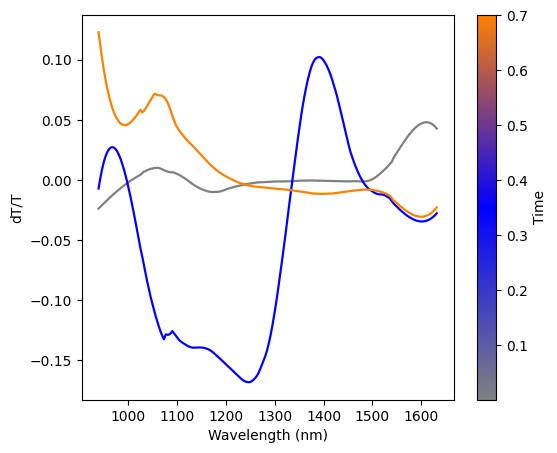

In [9]:
pl.plot_spectra_at_times(
    df, time_range=(0, 1), step=10,
    legend=False,figsize=(6,5)
)
plt.show()

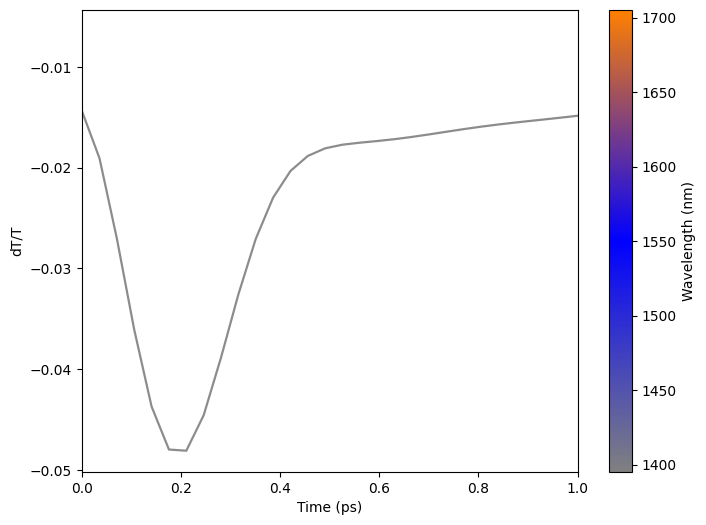

In [11]:
df_k = master_time[1]
df_k = df_k.drop(columns=["sample", "power_mW"])

pl.kinetic_plot(
    df_k, wavelengths=1550,xlim=[0,1]
)
plt.show()

In [ ]:
[1310, 1550, 1620]

In [ ]:
pl.plot_columns_in_range(
    out,
    low_time=0, high_time=0.5,step=3,
    legend=False,figsize=(6,5)
)
#plt.savefig("Pump_probe.svg", bbox_inches="tight")
plt.show()

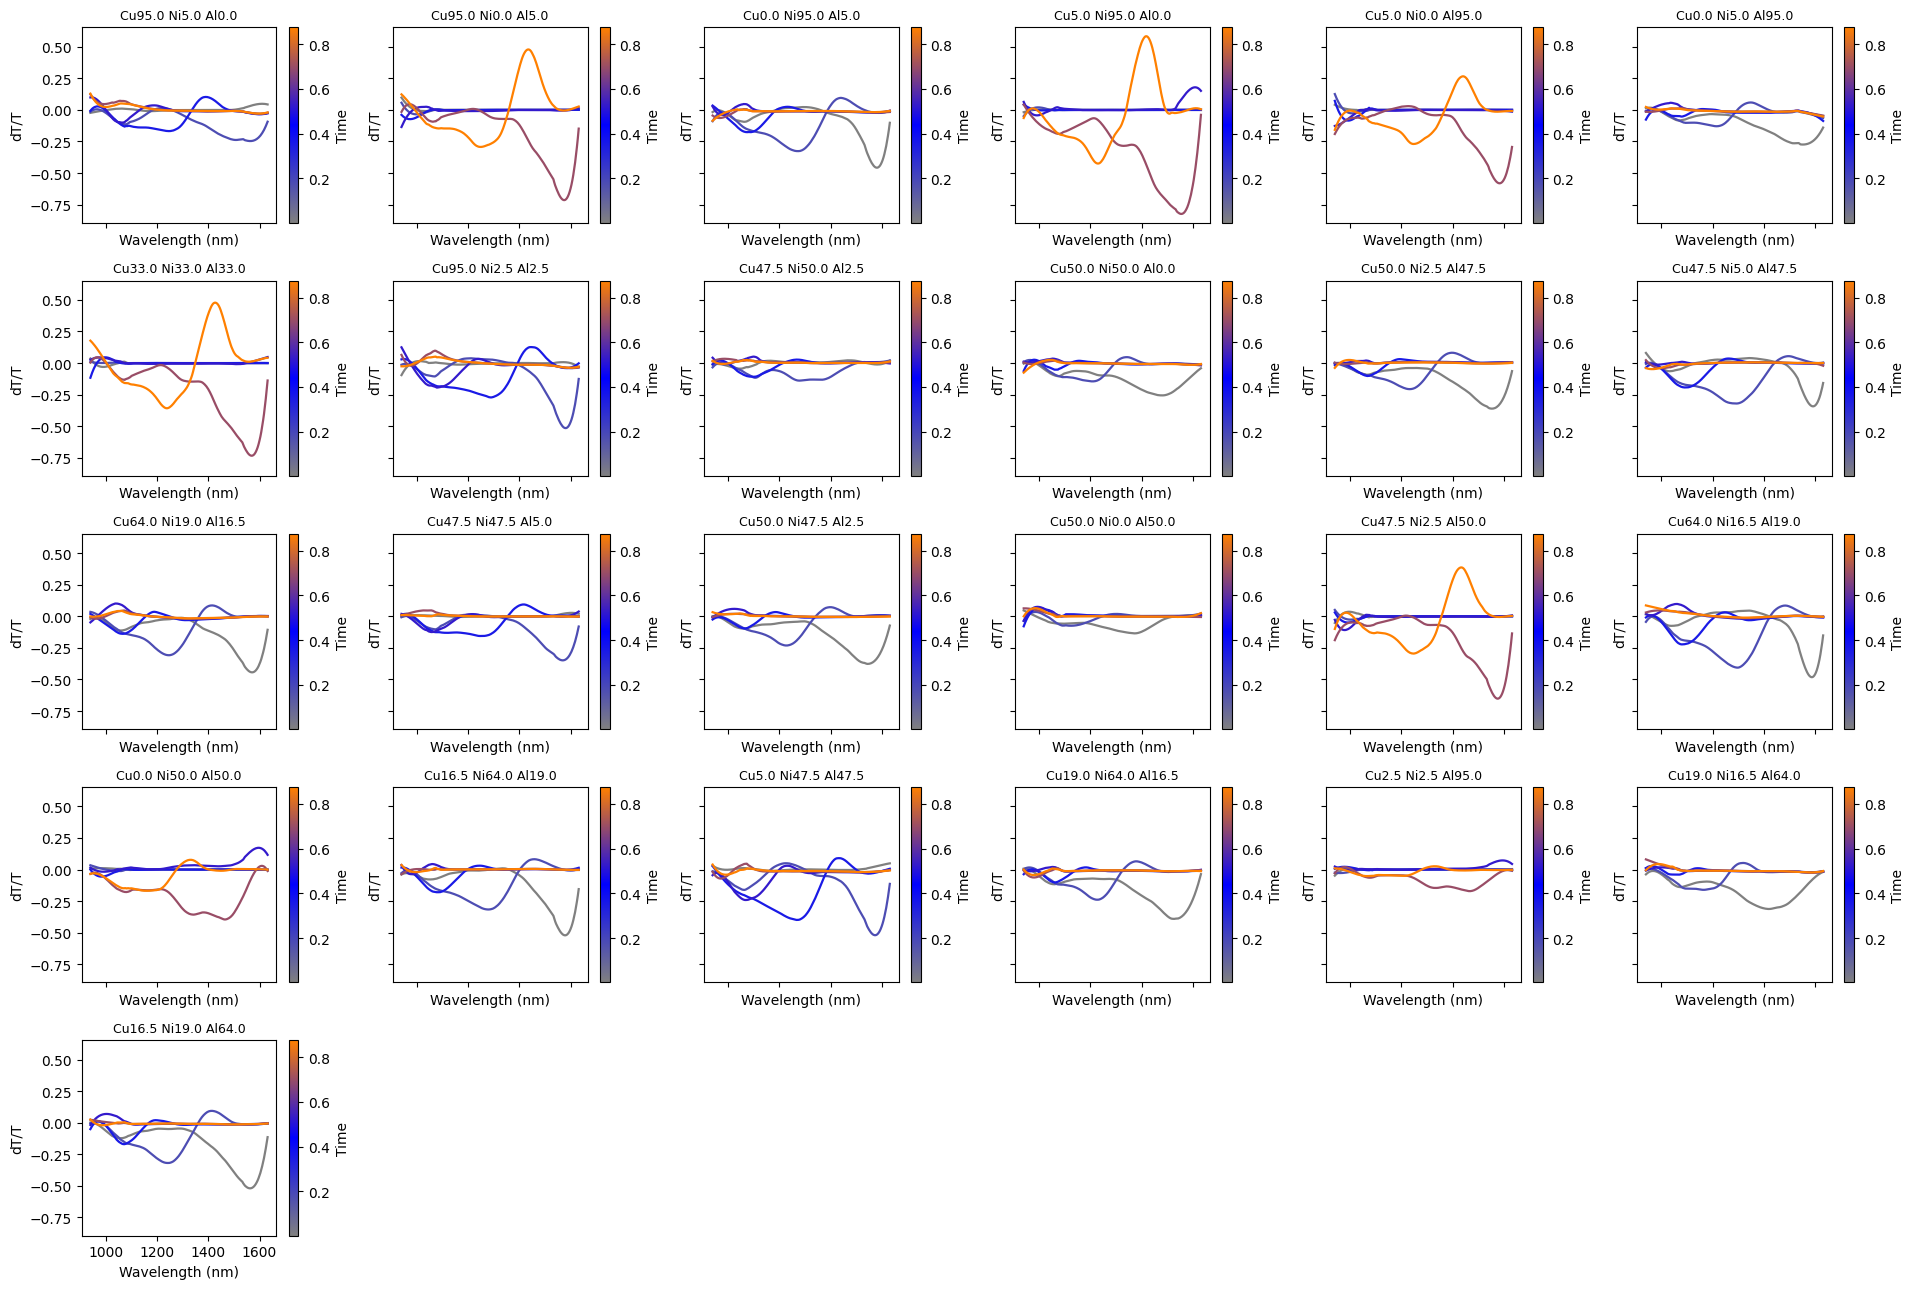

In [32]:
sample_data = np.array(list(master_wvl.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()

for ax, sample in zip(axes, sample_data):
    df = master_wvl[sample].drop(columns=["sample", "power_mW"])

    pl.plot_spectra_at_times(
        df,
        time_range=(0, 1),
        step=5,
        legend=False,
        ax=ax,         
        add_colorbar=True,
        figsize=(6,5)  
    )
    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Kinetic Plot

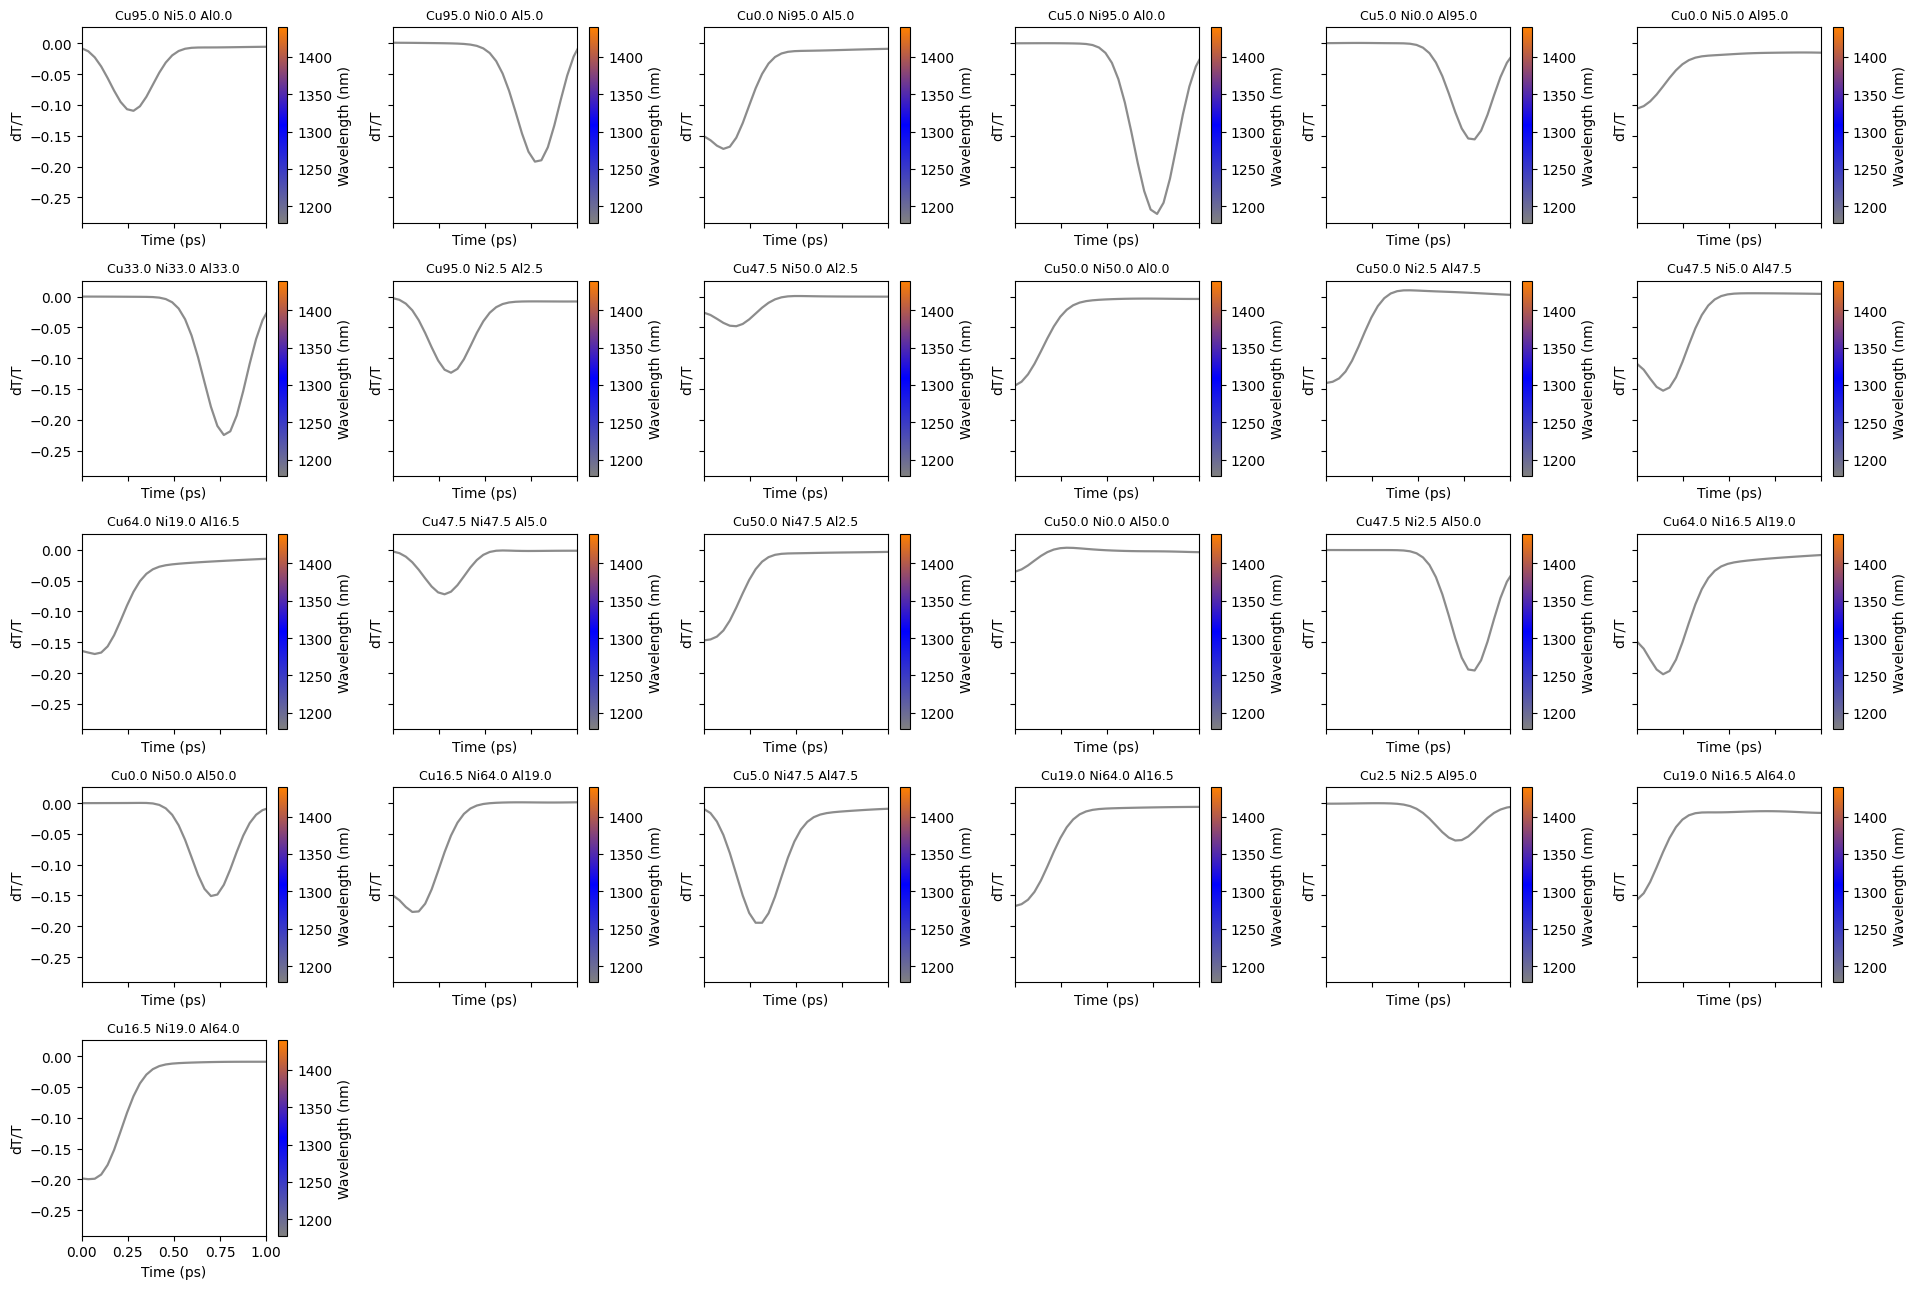

In [33]:
sample_data = np.array(list(master_time.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to 1D list of axes

for ax, sample in zip(axes, sample_data):
    df = master_time[sample]
    df = df.drop(columns=['sample', 'power_mW'])
    pl.kinetic_plot(df,wavelengths = [1308.8],xlim=(0, 1),ax=ax )
    
    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)


for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Lifetime calculation

In [20]:
df = master_dfs[1]
columns = ['sample','power_mW']
df = df.drop(columns=columns)

In [ ]:
lifetime = {}
wvl = 1308.8

for key, df in master_dfs.items():
    df = df.drop(columns=['sample', 'power_mW'])


    x = df.columns.to_numpy()

    idx = np.abs(df.index.to_numpy(dtype=float) - wvl).argmin()
    y = df.iloc[idx].to_numpy(dtype=float)

    lifetime[key] = lt.fit(time=x, y_exp=y)

In [33]:

def plot_lifetime_fit(
    lifetime: dict,
    key,
    time,
    y_exp,
    time_range=None,          # NEW: (tmin, tmax)
    figsize=(6, 4),
):
    """
    Plot experimental data vs fitted curve for a given key,
    optionally restricting to a time range.
    """

    fit_out = lifetime[key]
    y_fit = fit_out["y_fit"]
    r2 = fit_out.get("r2", None)

    time = np.asarray(time, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)

    if time_range is not None:
        tmin, tmax = time_range
        mask = (time >= tmin) & (time <= tmax)
    else:
        mask = slice(None)

    plt.figure(figsize=figsize)
    plt.plot(time[mask], y_exp[mask], "o", label="exp")

    if r2 is not None:
        plt.plot(time[mask], y_fit[mask], "-", label=f"fit (R² = {r2:.3f})")
    else:
        plt.plot(time[mask], y_fit[mask], "-", label="fit")

    if time_range is not None:
        plt.xlim(time_range)

    plt.xlabel("Time (ps)")
    plt.ylabel("dT/T")
    plt.legend()
    plt.tight_layout()
    plt.show()

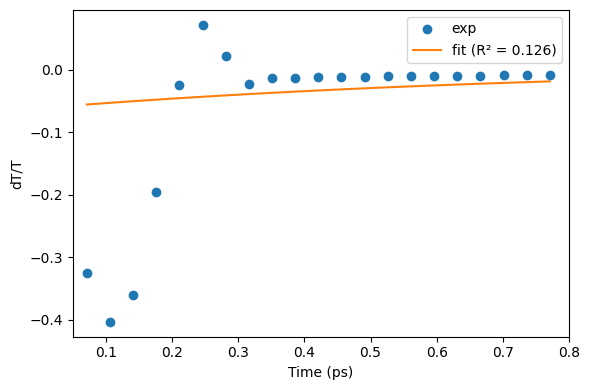

In [34]:
plot_lifetime_fit(
    lifetime=lifetime,
    key=1,
    time=x,
    y_exp=y,
    time_range=(0.05, 0.8),
)

Lifetime equation fitting
1. Functions of the equation and the objective function
2. Find initial guesses
3. Gradient-based search to find the minimum

In [135]:
path_test = 'sara_test_data.xlsx'
df_test = pd.read_excel(path_test,sheet_name='Au50Pd50')

df_test.head(5)
y_exp = df_test['dT/T exp'].to_numpy()
time = df_test['time (ps)'].to_numpy()
y_fit_sara = df_test['dT/T Fit'].to_numpy()

In [117]:
def model(time, dt_t_nt, tau_th, tau_p, dt_t_th, dt_t_l):
    return (
        dt_t_nt * np.exp(-time * ((1/tau_th) + (1/tau_p)))
        + dt_t_th * (np.exp(-time/tau_p) * (1 - np.exp(-time/tau_th)))
        + dt_t_l
    )

def objective(p, time, y_exp):
    y_fit = model(time, *p)
    r = y_fit - y_exp
    return np.sum(r*r)

def find_initial_guess(bounds, time, y_exp, n_samples=5000, seed=0):
    rng = np.random.default_rng(seed)

    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)

    best_p = None
    best_val = np.inf

    for _ in range(n_samples):
        p = lo + (hi - lo) * rng.random(len(bounds))
        val = objective(p, time, y_exp)
        if val < best_val:
            best_val = val
            best_p = p

    return best_p, best_val

In [143]:
def find_initial_guesses(bounds, time, y_exp, n_samples=5000, k_best=20, seed=0):
    rng = np.random.default_rng(seed)

    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)

    candidates = []

    for _ in range(n_samples):
        p = lo + (hi - lo) * rng.random(len(bounds))
        val = objective(p, time, y_exp)
        candidates.append((val, p))

    candidates.sort(key=lambda x: x[0])
    return [p for (_, p) in candidates[:k_best]]

In [149]:

y_scale = np.std(y_exp) if np.std(y_exp) > 0 else 1.0
tmin_pos = np.min(time[time > 0])
tmax = np.max(time)

bounds = [
    (-10*y_scale, 10*y_scale),   # dt_t_nt
    (tmin_pos*0.1, tmax*10),     # tau_th  (ps)
    (tmin_pos*0.1, tmax*10),     # tau_p   (ps)
    (-10*y_scale, 10*y_scale),   # dt_t_th
    (np.min(y_exp), np.max(y_exp))  # dt_t_l
]

p0, val0 = find_initial_guess(bounds, time, y_exp, n_samples=5000)

#--------- Solve equation for Local Minimum -----------------------#
lb = [b[0] for b in bounds]
ub = [b[1] for b in bounds]

scale = np.std(y_exp)
scale = scale if scale > 0 else 1.0

res = least_squares(
    fun=lambda p: (model(time, *p) - y_exp) / scale,
    x0=p0,
    bounds=(lb, ub),
    loss="linear"  # or "soft_l1" if you have outliers
)

p_opt = res.x
print("DE initial:", p0)
print("Refined:", p_opt)


DE initial: [-2.46303905e-02  3.29253229e+01  1.03636743e+00 -9.58679906e-02
  5.82287780e-03]
Refined: [-0.00616366  0.11890152  1.08341281 -0.04387921  0.01092919]


In [ ]:
p0_sara = [-1.08e-2,0.139898,0.74371,-6.28e-2,0.017520945]

In [150]:
y_fit = model(time, *p_opt)
residuals = (y_fit - y_exp)**2
mse = np.mean(residuals)
print('MSE:',mse)

residual_s = (y_fit_sara - y_exp)**2
mse_s = np.mean(residual_s)
print('MSE:',mse_s)

MSE: 1.2135957058256118e-06
MSE: 1.2135957117079583e-06


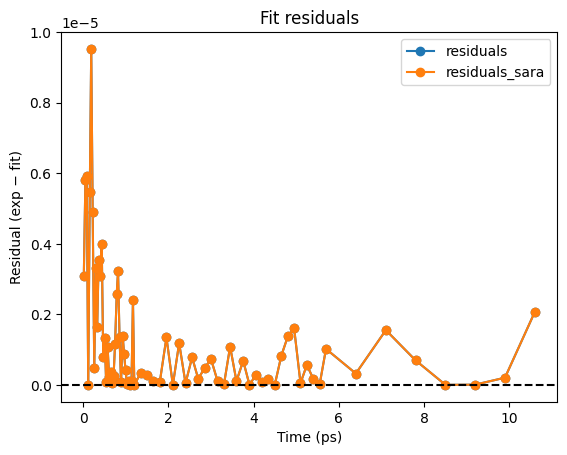

In [139]:
plt.plot(time, residuals, marker='o', label='residuals')
plt.plot(time, residual_s, marker='o', label='residuals_sara')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Time (ps)")
plt.ylabel("Residual (exp − fit)")
plt.title("Fit residuals")
plt.legend()
plt.show()

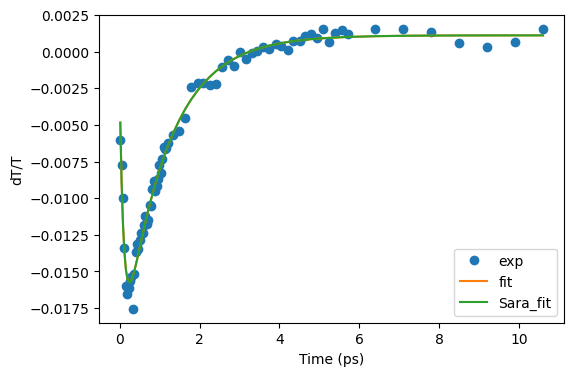

In [131]:
plt.figure(figsize=(6,4))
plt.plot(time, y_exp, 'o', label="exp")
plt.plot(time, y_fit, '-', label="fit")
plt.plot(time, y_fit_sara, '-', label="Sara_fit")
plt.xlabel("Time (ps)")
plt.ylabel("dT/T")
plt.legend()
plt.show()